# SET OF EXPERIMENTS WITH ML INPUTS AS SIGNAL RAW DATA
**Hypothesis:** This set of experiments are based on the hypothesis that models fet with the QRS information as raw data will have more information to do a better performance.

**Content of the file:** This file contains the two experiments done with the pure signal. First, a dataset combination assessment on the performance of the four machine learning algorithms: Random Forest, Logistic Regression, Support Vector Machine and Extreme Gradient Boosting (XGBoost). Then, a Convolutional Neural Network is defined to keep spatial information, and a dataset combination assessment is also performed on it. Finally, through a late fusion with an MLP, clinical data available for teknon dataset is introduced to the CNN.


### Imports & Paths

In [40]:
import os
import numpy as np
import pickle
import pandas as pd
import seaborn as sns
import math
import matplotlib.pyplot as plt
from typing import List,Tuple
from scipy import signal
from scipy.io import loadmat
import scipy as sp
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
from functools import partial
import shap
import xgboost as xgb
import skimage
import skimage.util
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import metrics


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [41]:
## If executing in colab, run these lines
'''from google.colab import drive
drive.mount('/content/drive')

BASE_PATH= "/content/drive/Shareddrives/CompBioMed/seminars"'''

'from google.colab import drive\ndrive.mount(\'/content/drive\')\n\nBASE_PATH= "/content/drive/Shareddrives/CompBioMed/seminars"'

Define the paths for all the experiments

In [42]:
BASE_PATH = ''

PATH_ALIGNED = os.path.join(BASE_PATH, "outputs", "aligned_qrs.pkl")
PATH_IDENTIFIERS = os.path.join(BASE_PATH, "outputs", "qrs_identifiers.pkl")
PATH_DATA = os.path.join(BASE_PATH, "data", "binary_full_dataset.parquet")

PATH_CARTO = os.path.join(BASE_PATH, "data", "QRS_CARTO2.mat")
PATH_CHINA = os.path.join(BASE_PATH, "data", "QRS_Database2.mat")
PATH_SIMS = os.path.join(BASE_PATH, "data", "QRS_Sims2.mat")


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'[INFO] Device: {device.upper()}')

os.makedirs('output/plots', exist_ok=True)

SAMPLE_SIZE = 277 # To include all the QRS signal
N_EPOCHS = 100
RANDOM_STATE = 42
BATCH_SIZE = 16
N_FOLDS = 5
LR = 0.001
WEIGHT_DECAY = 1e-4
ENABLE_SCHEDULER = True
SCHEDULER_TYPE = 'plateau'  # 'plateau' o 'cosine'
LEADS = ['I','II','III','AVR','AVL','AVF','V1','V2','V3','V4','V5','V6']


[INFO] Device: CPU


### Utilities

Functions defined to load the different datasets

In [43]:
def load_teknon():
    print('\n-- Loading Teknon ------------------------------------------')
    # Load alinged qrs
    with open(PATH_ALIGNED, 'rb') as f:
        aligned_ecgs = pickle.load(f)
    X_teknon_all = np.array(aligned_ecgs, dtype=np.float32)

    # Transpose to (n_samples, n_leads, n_timepoints)
    X_teknon_all = np.transpose(X_teknon_all, (0, 2, 1))

    #Load identifiers
    with open(PATH_IDENTIFIERS, 'rb') as f:
        df_id = pickle.load(f)

    # Load the clinical data to extract the labels (in column Chamber_Type)
    df_full  = pd.read_parquet(PATH_DATA)
    Y_tabular = df_full['Chamber_Type']

    # Synchronize the datasets based on the indices (patient IDs)
    indices_comuns = df_id.index.intersection(Y_tabular.index)
    print(f'  ECGs en pipeline        : {len(df_id)}')
    print(f'  Pacientes en parquet    : {len(Y_tabular)}')
    print(f'  Pacientes sincronizados : {len(indices_comuns)}')

    # Extract the synchronized ECGs and labels
    y_raw        = Y_tabular.loc[indices_comuns].values
    posicions_ecg = [df_id.index.get_loc(idx) for idx in indices_comuns]
    X_tek        = X_teknon_all[posicions_ecg]

    # Map the labels to 0-LV and 1-RV
    mapping = {'LV': 0, 'RV': 1}
    y_tek   = np.array([mapping[v] if v in mapping else int(v) for v in y_raw],
                       dtype=np.int64)

    print(f'  Shape ECGs              : {X_tek.shape}')
    print(f'  LV (0): {(y_tek==0).sum()}   RV (1): {(y_tek==1).sum()}')
    return X_tek, y_tek



In [44]:
def _build_binary_target(dSim, data_key):
    mapping  = {'LV': 0, 'RV': 1}
    key_name = ('LeftRight' if 'LeftRight' in dSim[data_key].dtype.names
                else 'LeftRigth')
    raw_labels = dSim[data_key][key_name]
    y = np.zeros(len(raw_labels[0]), dtype=np.int64)
    for i, label in enumerate(raw_labels[0]):
        y[i] = mapping[label[0]]
    return y


def _handle_sublocation(dSim: dict,
                        data_key: str,
                        path: str,
                        X: np.ndarray,
                        y: np.ndarray) -> (np.ndarray, np.ndarray, np.ndarray):
    """
    Handle sublocation classification and remove invalid samples.
    """

    mapping = {
        'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOT Subvalvular': 3,
        'LVOT Summit': 4, 'RVOT Septum': 5, 'RFW': 6,
        'Undefined': 7
    }

    raw_labels = dSim[data_key]["Sublocation"]

    y_sub = []
    valid_indices = []
    unique_labels = []

    for i, label in enumerate(raw_labels[0]):
        try:
            if len(label) == 0:
                label_str = 'Undefined'
            else:
                label_str = label[0]

            # Include other sublocation names in the mapping
            if label_str in ['LCCRCC', 'LCC-RCC']:
                label_str = 'COMMISSURE'
            elif label_str in ['Posteroseptal', 'Anteroseptal']:
                label_str = 'RVOT Septum'
            elif label_str == "AMC":
                label_str = 'LVOT Subvalvular'
            elif label_str == "Summit":
                label_str = 'LVOT Summit'
            elif label_str in ["RV", "-", "RVOTOther"]:
                label_str = 'Undefined'

            # Map the sublocation label to its corresponding integer value
            if label_str in mapping:
                y_sub.append(mapping[label_str])
                valid_indices.append(i)
                if label_str not in unique_labels:
                    unique_labels.append(label_str)
            else:
                print(f"Warning: unknown sublocation '{label_str}' at index {i}")

        except Exception as e:
            print(f"Warning: error at index {i} with label {label}: {e}")
            continue

    print(f"Unique sublocation labels found: {unique_labels}")

    # Keep only valid samples
    X = X[valid_indices]
    y = y[valid_indices]
    y_sub = np.array(y_sub)

    return X, y, y_sub


In [45]:
def _load_mat_dataset(path, sample_size, data_key, lead_names, sublocation):
    dSim = loadmat(path)
    n_patients = dSim[data_key][lead_names[0]].shape[1]
    print(f"Number of patients in file: {n_patients}")

    #Initialize X and y_sub
    X = np.zeros((n_patients, len(lead_names), sample_size))
    y_sub = None

    # Process each lead and patient
    for iLead, lead in enumerate(lead_names):
        lead_data = dSim[data_key][lead]
        for i in range(n_patients):
            patient_signal = lead_data[0, i]
            signal_1d = np.asarray(patient_signal).squeeze()

            if signal_1d.ndim != 1:
                continue

            resampled = signal.resample(signal_1d, sample_size)

            if np.max(np.abs(resampled)) > 0:
                resampled = resampled / np.max(np.abs(resampled))

            X[i, iLead, :] = resampled

    y = _build_binary_target(dSim, data_key)

    if sublocation:
        # Handle sublocation classification
        X, y, y_sub = _handle_sublocation(dSim, data_key, path, X, y)

    return {
        "data": X,
        "target": y,
        "subtarget": y_sub
    }

def load_dataset(path: str,
                 sample_size: int,
                 data_key: str,
                 lead_names: list = None,
                 sublocation: bool = False,
                 shuffle: bool = True,
                 random_state: int = None):

    if lead_names is None:
        lead_names = ["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"]

    print(f"\n--- Loading dataset from: {path} ---")

    DB_dict = _load_mat_dataset(path, sample_size=sample_size, data_key=data_key,
                                lead_names=lead_names, sublocation=sublocation)

    X = DB_dict["data"]
    y = DB_dict["target"]
    y_sub = DB_dict["subtarget"]

    # Shuffling
    if shuffle:
        rng = np.random.default_rng(random_state)
        indices = rng.permutation(len(X))
        X = X[indices]
        y = y[indices]
        if y_sub is not None:
            y_sub = y_sub[indices]

    if sublocation:
        return X, y, y_sub
    return X, y



Function to handle the raw data 

In [46]:
def preprocess_ecg(ecg, target_leads=12, target_len=277):
    """
    Transform any input to the targeted size (12, 277)
    """
    # Convert to torch tensor
    if not isinstance(ecg, torch.Tensor):
        ecg = torch.tensor(ecg, dtype=torch.float32)

    # For china/sims case (120,), convert to 12 leads x 10 points
    if ecg.ndim == 1 and ecg.shape[0] == 120:
        ecg = ecg.reshape(12, 10)

    # Adjust channels (leads)
    if ecg.ndim == 1: # If it's single channel
        ecg = ecg.unsqueeze(0).repeat(target_leads, 1)

    # Adjust temporal length (Padding or Cropping)
    current_len = ecg.shape[1]

    if current_len < target_len:
        # Padding: add zeroes at he end
        padding_needed = target_len - current_len
        ecg = F.pad(ecg, (0, padding_needed))
    else:
        # Crop: cut to center the signal
        ecg = ecg[:, :target_len]
    return ecg

In [70]:
class UniversalECGDataset(Dataset):
    def __init__(self, X_ecg, y, X_tabular=None, num_tab_features=19, return_tab =False):
        self.X_ecg = X_ecg
        self.y = torch.tensor(y, dtype=torch.long)
        self.num_tab_features = num_tab_features
        self.X_tabular = torch.tensor(X_tabular, dtype=torch.float32) if X_tabular is not None else None
        self.return_tab = return_tab

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Apply the transformation function to ensure equal shape
        ecg = preprocess_ecg(self.X_ecg[idx])
        label = self.y[idx]

        # don't return tabular variables if not expected
        if not self.return_tab:                                       
            return ecg, label
        
        # Include tabular data if available, for last experiment
        if self.X_tabular is not None:
            tab = self.X_tabular[idx]

        else:
            tab = torch.zeros(self.num_tab_features)
        return ecg, tab, label
    
    
class ECG_CNN(nn.Module):
    """CNN model based on Saglietto et al. with added maxpoolings to reduce dimensionality"""
    
    def __init__(self, n_leads=12, dropout=0.2):
        super(ECG_CNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(n_leads, 32, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),

            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.feature_layer = nn.Sequential(
            nn.Linear(128, 8),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(8, 2)

    def forward(self, x):
        x        = self.conv_block(x)
        x        = x.view(x.size(0), -1)
        features = self.feature_layer(x)
        return self.classifier(features)

Function described to train Cross-Validation with 5 folds evaluating only on teknon.

In [48]:

def cross_validation(X_tek_3d, y_tek, X_extra_3d=None, y_extra=None):
    """
    Execute cross validation of 5 folds where validation is done exclusively on teknon patients. The extra data is only added to the training set.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    models = {
        'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
        'LogReg': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
        'SVM_RBF': Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=RANDOM_STATE))]),
        'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)
    }

    resultats_models = {}

    X_tek_flat = X_tek_3d.reshape(X_tek_3d.shape[0], -1)


    if X_extra_3d is not None and len(X_extra_3d) > 0:
        X_extra_flat = X_extra_3d.reshape(X_extra_3d.shape[0], -1)
    else:
        X_extra_flat = None

    for name, clf in models.items():
        aucs = []
        for tr_idx, val_idx in skf.split(X_tek_flat, y_tek):
            X_train_fold = X_tek_flat[tr_idx]
            y_train_fold = y_tek[tr_idx]

            if X_extra_flat is not None:
                X_train_fold = np.concatenate([X_train_fold, X_extra_flat], axis=0)
                y_train_fold = np.concatenate([y_train_fold, y_extra], axis=0)


            clf.fit(X_train_fold, y_train_fold)

            # Exclusively evaluate on pure teknon
            proba = clf.predict_proba(X_tek_flat[val_idx])[:, 1]
            preds = clf.predict(X_tek_flat[val_idx])
            aucs.append(f1_score(y_tek[val_idx], preds, average='macro'))

        resultats_models[f'{name} (Macro F1)'] = np.mean(aucs)

    return resultats_models


Functions defined for the training and evaluation of the CNN

In [49]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Trains the model for one epoch on the given loader and returns the average loss."""

    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb, = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_loss(model, loader, criterion):
    """Calculates the average loss on the given loader without updating the model."""

    model.eval()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict(model, loader):
    """Generates predictions and probabilities for the given loader"""
    model.eval()
    trues, probas, preds = [], [], []
    for xb, yb in loader:
        xb     = xb.to(device)
        logits = model(xb)
        prob   = F.softmax(logits, dim=1).cpu().numpy()
        pred   = logits.argmax(dim=1).cpu().numpy()
        trues.append(yb.numpy())
        probas.append(prob)
        preds.append(pred)
    return (np.concatenate(trues),
            np.concatenate(probas),
            np.concatenate(preds))


def compute_metrics(y_true, y_proba, y_pred):
    """Computes the metrics, we are especially interested on F1"""
    auc  = roc_auc_score(y_true, y_proba[:, 1])
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    return {'AUC': auc, 'Accuracy': acc, 'F1': f1,
            'Sensitivity': sens, 'Specificity': spec}

In [50]:
def plot_loss_curves(train_losses, val_losses, fold, exp_name):
    """
    Displays the loss curves for training and validation in each fold.
    Also returns True if possible early overfitting is detected.
    """
    epochs = range(1, len(train_losses) + 1)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(epochs, train_losses, label='Train loss', color='steelblue')
    ax.plot(epochs, val_losses,   label='Val loss (Teknon)', color='tomato',
            linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.set_title(f'{exp_name}  |  Fold {fold}')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Simple overfitting diagnose, if val_loss rises more than 0.1 in the first 10 epochs -> alert
    if len(val_losses) >= 10:
        early_val_min = min(val_losses[:10])
        early_val_max = max(val_losses[:10])
        overfit_flag  = (early_val_max - early_val_min) > 0.10
    else:
        overfit_flag = False

    return overfit_flag

def plot_all_folds_summary(all_fold_losses, exp_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for fold_i, (train_losses, val_losses) in enumerate(all_fold_losses, 1):
        epochs = range(1, len(train_losses) + 1)
        axes[0].plot(epochs, train_losses, label=f'Fold {fold_i}', alpha=0.7)
        axes[1].plot(epochs, val_losses,   label=f'Fold {fold_i}', alpha=0.7)

    axes[0].set_title(f'{exp_name}  |  Train loss')
    axes[1].set_title(f'{exp_name}  |  Val loss (Teknon)')
    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Cross-entropy loss')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [51]:

def train_and_eval_fold(X_train, y_train, X_val_tek, y_val_tek, fold, exp_name):
    """
    Versió optimitzada de train_and_eval_fold.
    S'ha eliminat la recollida de brossa manual (gc/cuda cache) i s'han agilitzat
    els passos interns per accelerar el temps per fold.
    """

    ds_train = UniversalECGDataset(X_train, y_train)
    ds_val   = UniversalECGDataset(X_val_tek, y_val_tek)


    dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
    dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)

    # Initializing model, optimizer, criterion & scheduler configuration
    model     = ECG_CNN(n_leads=12).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    scheduler = None
    if ENABLE_SCHEDULER:
        if SCHEDULER_TYPE == 'plateau':
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5)
        elif SCHEDULER_TYPE == 'cosine':
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=N_EPOCHS, eta_min=LR / 100)

    train_losses, val_losses = [], []
    best_f1, best_state     = 0.0, None

    # Epochs loop with best checkopint
    for epoch in range(1, N_EPOCHS + 1):
        tr_loss  = train_one_epoch(model, dl_train, optimizer, criterion)
        val_loss = eval_loss(model, dl_val, criterion)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        # Update the scheduler
        if scheduler is not None:
            if SCHEDULER_TYPE == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if epoch % 5 == 0 or epoch == N_EPOCHS:
            y_true, y_proba, y_pred = predict(model, dl_val)
            metrics = compute_metrics(y_true, y_proba, y_pred)
            if metrics['F1'] > best_f1:
                best_f1   = metrics['F1']
                best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # Evaluate the best model
    model.load_state_dict(best_state)
    y_true, y_proba, y_pred = predict(model, dl_val)
    final = compute_metrics(y_true, y_proba, y_pred)

    return final, train_losses, val_losses, best_state

In [62]:
def run_experiment_cnn(exp_id, exp_name, X_teknon, y_teknon, X_test, y_test, X_extra_3d=None, y_extra=None):
    """
    Controls the cross-val strategy on Teknon for a specific experiment.
    Injects extra data into the Train and evaluates exclusively against Teknon Val.
    """

    print(f"Starting combination: {exp_id} - {exp_name}")

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []

    best_overall_f1 = 0.0
    best_model_weights = None
    all_fold_losses = []

    # Fold split exclusively on teknon
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_teknon, y_teknon), 1):
        print(f"  → Training Fold {fold}/{N_FOLDS}...")

        # train-val split (only teknon) for this fold
        X_train_fold = X_teknon[tr_idx]
        y_train_fold = y_teknon[tr_idx]

        X_val_fold = X_teknon[val_idx]
        y_val_fold = y_teknon[val_idx]

        # add the other datasets (??)
        if X_extra_3d is not None and len(X_extra_3d) > 0:
            X_train_fold = np.concatenate([X_train_fold, X_extra_3d], axis=0)
            y_train_fold = np.concatenate([y_train_fold, y_extra], axis=0)


        metrics_dict, tloss, vloss, fold_best_state = train_and_eval_fold(
            X_train=X_train_fold,
            y_train=y_train_fold,
            X_val_tek=X_val_fold,
            y_val_tek=y_val_fold,
            fold=fold,
            exp_name=f"{exp_id}_{exp_name}"
        )

        fold_results.append(metrics_dict)
        all_fold_losses.append((tloss, vloss))

        # Save the best model for hold-out evaluation
        if metrics_dict['F1'] > best_overall_f1:
            best_overall_f1 = metrics_dict['F1']
            best_model_weights = fold_best_state

    # Calculate the mean F1 across folds for this experiment
    mean_f1 = np.mean([f['F1'] for f in fold_results])
    print(f"{exp_id} has ended -> F1 Mean on Teknon: {mean_f1:.4f}")

    # Evaluation on the hold-out test set with the best model from CV
    print(f"  → Evaluating the best model from CV on the Teknon Test Set...")
    model_test = ECG_CNN(n_leads=12).to(device)
    model_test.load_state_dict(best_model_weights)

    ds_test = UniversalECGDataset(X_test, y_test)
    dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

    y_true_test, y_proba_test, y_pred_test = predict(model_test, dl_test)
    test_metrics = compute_metrics(y_true_test, y_proba_test, y_pred_test)
    test_f1 = test_metrics['F1']

    # Training curves
    plot_all_folds_summary(all_fold_losses, f"{exp_id}_{exp_name}")
    
    # Confusion matrix plot for the hold-out test set
    cm = confusion_matrix(y_true_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LV (0)', 'RV (1)'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')

    ax.set_title(f"CNN - {exp_name}\nTest Macro F1: {test_f1:.4f}", fontsize=11, pad=10)

    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label (Teknon Test)', fontsize=10)
    plt.tight_layout()

    return mean_f1

Function to evaluate the logistic regression model in the best experiments

In [53]:
def evaluate_and_plot_logreg(X_train_tek, y_train_tek, X_test_tek, y_test_tek, X_extra_3d=None, y_extra=None, exp_name=""):
    """
    Trains a Logistic Regression pipeline and evaluates it on the test set.
    Generates a clean confusion matrix plot using ConfusionMatrixDisplay.
    """
    # Flatten 3D arrays to 2D matrix (samples, features)
    X_train_flat = X_train_tek.reshape(X_train_tek.shape[0], -1)
    X_test_flat = X_test_tek.reshape(X_test_tek.shape[0], -1)

    # Merge external data into training set if provided
    if X_extra_3d is not None and len(X_extra_3d) > 0:
        X_extra_flat = X_extra_3d.reshape(X_extra_3d.shape[0], -1)
        X_train_final = np.concatenate([X_train_flat, X_extra_flat], axis=0)
        y_train_final = np.concatenate([y_train_tek, y_extra], axis=0)
    else:
        X_train_final = X_train_flat
        y_train_final = y_train_tek

    # Standard scale features and train Logistic Regression
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])
    pipeline.fit(X_train_final, y_train_final)

    # Predictions and metrics
    preds = pipeline.predict(X_test_flat)
    f1_macro = f1_score(y_test_tek, preds, average='macro')
    cm = confusion_matrix(y_test_tek, preds)

    # Plot using ConfusionMatrixDisplay
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    display_labels = ['LV (0)', 'RV (1)']

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')

    ax.set_title(f"LogReg - {exp_name}\nTest Macro F1: {f1_macro:.4f}", fontsize=11, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label (Teknon Test)', fontsize=10)
    plt.tight_layout()

    # Display the output image
    plt.show()
    plt.close()

    return {
        'Experiment': exp_name,
        'Test Macro F1': f1_macro,
        'TN': cm[0][0], 'FP': cm[0][1],
        'FN': cm[1][0], 'TP': cm[1][1]
    }

Class & functions utilities for CNN+MLP experiment

In [54]:
#### Network architectures
class ClinicalMLP(nn.Module):
    def __init__(self, input_size=14):
        super(ClinicalMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.bn1 = nn.BatchNorm1d(16)
        self.fc2 = nn.Linear(16, 8)
        self.bn2 = nn.BatchNorm1d(8)
        self.dropout = nn.Dropout(0.2)
        self.classifier_layer = nn.Linear(8, 2)

    def forward(self, x, return_features=False):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        features = torch.relu(self.bn2(self.fc2(x)))
        if return_features:
            return features
        return self.classifier_layer(features)
    
class ECG_CNN_Cropped(nn.Module):
    def __init__(self, n_leads=12):
        super(ECG_CNN_Cropped, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(n_leads, 32, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),

            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.feature_layer = nn.Linear(128, 8)

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)
        return self.feature_layer(x)


class GlobalFusionModel(nn.Module):
    def __init__(self, cnn_model, mlp_model):
        super(GlobalFusionModel, self).__init__()
        self.cnn = cnn_model
        self.mlp = mlp_model
        self.final_classifier = nn.Sequential(
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x_ecg, x_tab):
        feat_ecg = self.cnn(x_ecg)
        feat_tab = self.mlp(x_tab, return_features=True)
        combined = torch.cat((feat_ecg, feat_tab), dim=1)
        return self.final_classifier(combined)


In [55]:
### Traininf and validation pipelines
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs_ecg, inputs_tab, labels in train_loader:
        inputs_ecg, inputs_tab, labels = inputs_ecg.to(device), inputs_tab.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs_ecg, inputs_tab)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs_ecg.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100. * correct / total

def validate_model(model, val_loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs_ecg, inputs_tab, labels in val_loader:
            inputs_ecg, inputs_tab, labels = inputs_ecg.to(device), inputs_tab.to(device), labels.to(device)
            outputs = model(inputs_ecg, inputs_tab)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs_ecg.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100. * correct / total


### 1. Machine Learning on Raw Data
This experiment includes a dataset combination assessment with a evaluation on a hold-out test set (last 20% of Teknon data)

In [56]:
X_all, y_all = load_teknon()

# Define the hold-out test set
split_idx = int(0.8 * len(y_all))
X_teknon = X_all[:split_idx]
y_teknon = y_all[:split_idx]
X_test = X_all[split_idx:]
y_test = y_all[split_idx:]

# Load the extra datasets
X_Sims, y_Sims, y_sub_Sims = load_dataset(PATH_SIMS, sample_size=SAMPLE_SIZE, data_key='QRS_Sims', sublocation=True, shuffle=False)
X_China, y_China, y_sub_China = load_dataset(PATH_CHINA, sample_size=SAMPLE_SIZE, data_key='QRS', sublocation=True, shuffle=False)
X_Clinic, y_Clinic, y_sub_Clinic = load_dataset(PATH_CARTO, sample_size=SAMPLE_SIZE, data_key='QRS_CARTO', sublocation=True, shuffle=False)


-- Loading Teknon ------------------------------------------
  ECGs en pipeline        : 178
  Pacientes en parquet    : 180
  Pacientes sincronizados : 177
  Shape ECGs              : (177, 12, 277)
  LV (0): 74   RV (1): 103

--- Loading dataset from: data\QRS_Sims2.mat ---
Number of patients in file: 2496
Unique sublocation labels found: ['LCC', 'COMMISSURE', 'RCC', 'LVOT Subvalvular', 'LVOT Summit', 'RVOT Septum', 'RFW']

--- Loading dataset from: data\QRS_Database2.mat ---
Number of patients in file: 333
Unique sublocation labels found: ['RFW', 'RVOT Septum', 'RCC', 'LCC', 'Undefined', 'LVOT Summit', 'LVOT Subvalvular', 'COMMISSURE']

--- Loading dataset from: data\QRS_CARTO2.mat ---
Number of patients in file: 43
Unique sublocation labels found: ['RCC', 'LCC', 'Undefined', 'COMMISSURE']


After loading the datasets, a brief check to see that every dataset includes what is expected is done. 

In [57]:
# Inverse mapping to show the names
map_binary = {0: "LV", 1: "RV"}
map_sub = {
    0: 'LCC', 1: 'RCC', 2: 'COMMISSURE', 3: 'LVOT Subvalvular',
    4: 'LVOT Summit', 5: 'RVOT Septum', 6: 'RFW (RVOT Free Wall)', 7: 'Generic/Unknown'
}

datasets = {
    "Sims": (y_Sims, y_sub_Sims),
    "Database2": (y_China, y_sub_China),
    "CARTO2": (y_Clinic, y_sub_Clinic)}

for name, (y, y_sub) in datasets.items():
    print(f"Dataset Statistics: {name.upper()}")
    print(f"Valid patients: {len(y)}")

    # Counts for Binary Target
    print("\n  · Binary Target (Site of Origin):")
    vals_b, counts_b = np.unique(y, return_counts=True)
    for v, c in zip(vals_b, counts_b):
        label_name = map_binary.get(v, f"Unknown ({v})")
        print(f"    - {label_name:<15}: {c} patients ({c/len(y)*100:.1f}%)")

    # Counts for Sublocalizations
    if y_sub is not None:
        print("\n  · Sublocations:")
        vals_s, counts_s = np.unique(y_sub, return_counts=True)
        for v, c in zip(vals_s, counts_s):
            sub_name = map_sub.get(v, f"Unknown ({v})")
            print(f"    - [{v}] {sub_name:<22}: {c} patients")
    else:
        print("\n  · Sublocations: No available.")

Dataset Statistics: SIMS
Valid patients: 2496

  · Binary Target (Site of Origin):
    - LV             : 1456 patients (58.3%)
    - RV             : 1040 patients (41.7%)

  · Sublocations:
    - [0] LCC                   : 416 patients
    - [1] RCC                   : 416 patients
    - [2] COMMISSURE            : 208 patients
    - [3] LVOT Subvalvular      : 208 patients
    - [4] LVOT Summit           : 208 patients
    - [5] RVOT Septum           : 832 patients
    - [6] RFW (RVOT Free Wall)  : 208 patients
Dataset Statistics: DATABASE2
Valid patients: 333

  · Binary Target (Site of Origin):
    - LV             : 77 patients (23.1%)
    - RV             : 256 patients (76.9%)

  · Sublocations:
    - [0] LCC                   : 39 patients
    - [1] RCC                   : 7 patients
    - [2] COMMISSURE            : 7 patients
    - [3] LVOT Subvalvular      : 18 patients
    - [4] LVOT Summit           : 5 patients
    - [5] RVOT Septum           : 131 patients
    - [6] RF

Experiments loop: Train ML with all the combinations and assess F1 score only on teknon

In [58]:
# experiment loop
print("Starting teknon evaluation with traditional ML models...")
resum_real = []

# exp0: Only Teknon
resum_real.append({'Experiment': 'exp0: only Teknon', **cross_validation(X_teknon, y_teknon)})

# exp1: Sims + Tek
resum_real.append({'Experiment': 'exp1: Sims + Teknon', **cross_validation(X_teknon, y_teknon, X_Sims, y_Sims)})
resum_real.append({'Experiment': 'exp2: China + Teknon', **cross_validation(X_teknon, y_teknon, X_China, y_China)})

# exp3: Clinic (CARTO) + Tek
resum_real.append({'Experiment': 'exp3: CARTO + Teknon', **cross_validation(X_teknon, y_teknon, X_Clinic, y_Clinic)})

# exp4: China + Sims + Tek
X_e4 = np.concatenate([X_China, X_Sims], axis=0)
y_e4 = np.concatenate([y_China, y_Sims], axis=0)
resum_real.append({'Experiment': 'exp4: China + Sims + Teknon', **cross_validation(X_teknon, y_teknon, X_e4, y_e4)})

# exp5: Clinic + Sims + Tek
X_e5 = np.concatenate([X_Clinic, X_Sims], axis=0)
y_e5 = np.concatenate([y_Clinic, y_Sims], axis=0)
resum_real.append({'Experiment': 'exp5: CARTO + Sims + Teknon', **cross_validation(X_teknon, y_teknon, X_e5, y_e5)})

# exp6: Clinic + China + Tek
X_e6 = np.concatenate([X_Clinic, X_China], axis=0)
y_e6 = np.concatenate([y_Clinic, y_China], axis=0)
resum_real.append({'Experiment': 'exp6: CARTO + China + Teknon', **cross_validation(X_teknon, y_teknon, X_e6, y_e6)})

# exp7: ALL
X_all = np.concatenate([X_Clinic, X_China, X_Sims], axis=0)
y_all = np.concatenate([y_Clinic, y_China, y_Sims], axis=0)
resum_real.append({'Experiment': 'exp7: TOTS JUNTS (All)', **cross_validation(X_teknon, y_teknon, X_all, y_all)})

df_resum_real = pd.DataFrame(resum_real)
display(df_resum_real)

Starting teknon evaluation with traditional ML models...


,Experiment,RandomForest (Macro F1),LogReg (Macro F1),SVM_RBF (Macro F1),XGBoost (Macro F1)
0,exp0: only Teknon,0.550758,0.555543,0.428312,0.525933
1,exp1: Sims + Teknon,0.507648,0.602269,0.506773,0.489019
2,exp2: China + Teknon,0.446645,0.568943,0.399970,0.531613
3,exp3: CARTO + Teknon,0.559002,0.599134,0.445375,0.485859
4,exp4: China + Sims + Teknon,0.495911,0.537254,0.435227,0.536947
5,exp5: CARTO + Sims + Teknon,0.538459,0.610905,0.519435,0.576206
6,exp6: CARTO + China + Teknon,0.511141,0.535475,0.411829,0.532602
7,exp7: TOTS JUNTS (All),0.515187,0.552572,0.427041,0.532277


Given that the Logistic Regression is the algorithm giving higher CV F1, every dataset combination is then evaluated in the hold-out Teknon 20% cases. The Confusion Matrix with the F1 score values are displayed for every combination.

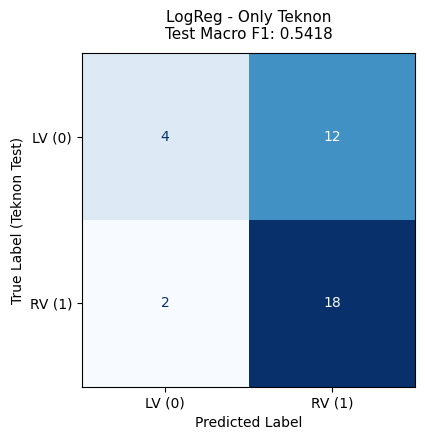

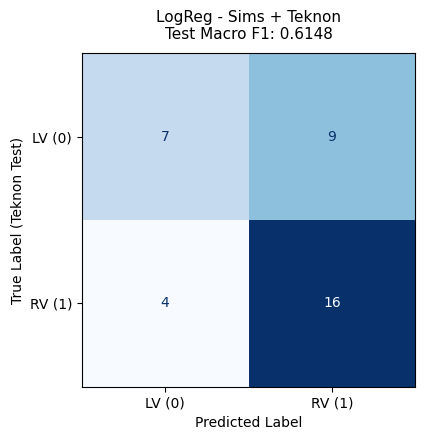

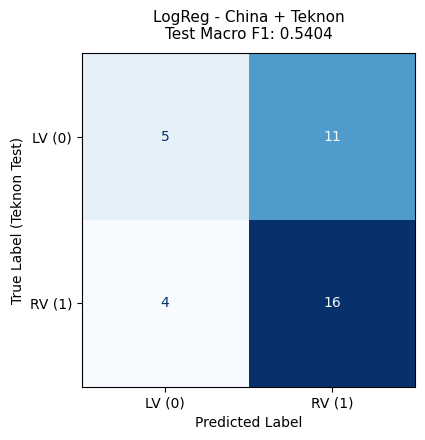

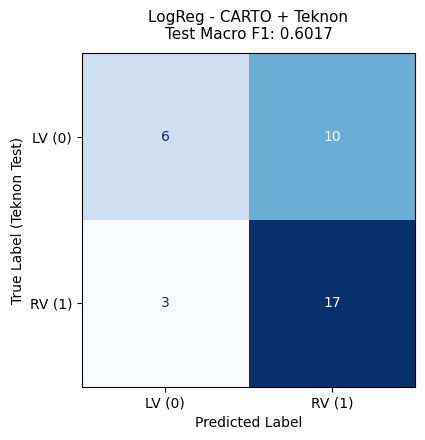

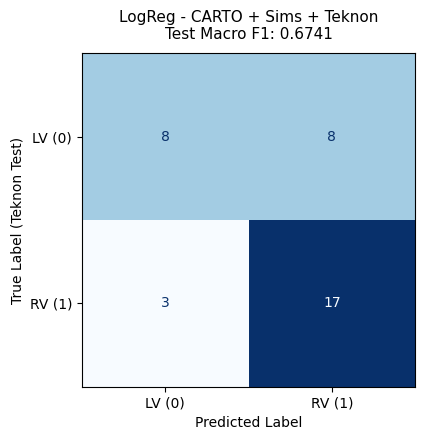

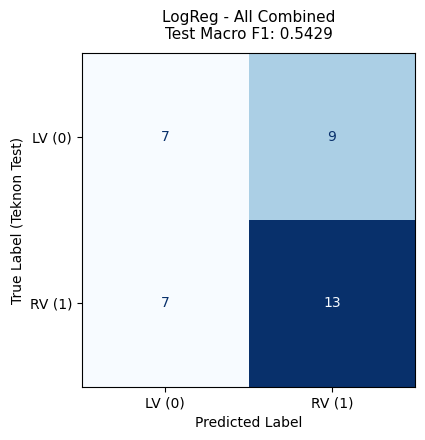

,Experiment,Test Macro F1,TN,FP,FN,TP
0,Only Teknon,0.541818,4,12,2,18
1,Sims + Teknon,0.614815,7,9,4,16
2,China + Teknon,0.540426,5,11,4,16
3,CARTO + Teknon,0.601702,6,10,3,17
4,CARTO + Sims + Teknon,0.674074,8,8,3,17
5,All Combined,0.542857,7,9,7,13


In [64]:

# Master equation loop
results = []

# exp0: Only Teknon
results.append(evaluate_and_plot_logreg(
    X_teknon, y_teknon, X_test, y_test, exp_name='Only Teknon'
))

# exp1: Sims + Teknon
results.append(evaluate_and_plot_logreg(
    X_teknon, y_teknon, X_test, y_test, X_Sims, y_Sims, exp_name='Sims + Teknon'
))

# exp2: China + Teknon
results.append(evaluate_and_plot_logreg(
    X_teknon, y_teknon, X_test, y_test, X_China, y_China, exp_name='China + Teknon'
))

# exp3: CARTO + Teknon
results.append(evaluate_and_plot_logreg(
    X_teknon, y_teknon, X_test, y_test, X_Clinic, y_Clinic, exp_name='CARTO + Teknon'
))

# exp5: CARTO + Sims + Teknon
X_e5 = np.concatenate([X_Clinic, X_Sims], axis=0)
y_e5 = np.concatenate([y_Clinic, y_Sims], axis=0)
results.append(evaluate_and_plot_logreg(
    X_teknon, y_teknon, X_test, y_test, X_e5, y_e5, exp_name='CARTO + Sims + Teknon'
))

# exp7: All Combined
X_all_extra = np.concatenate([X_Clinic, X_China, X_Sims], axis=0)
y_all_extra = np.concatenate([y_Clinic, y_China, y_Sims], axis=0)
results.append(evaluate_and_plot_logreg(
    X_teknon, y_teknon, X_test, y_test, X_all_extra, y_all_extra, exp_name='All Combined'
))

# Summary table
df_summary = pd.DataFrame(results)
display(df_summary[['Experiment', 'Test Macro F1', 'TN', 'FP', 'FN', 'TP']])

### 2. Convolutional Neural Networks on Raw Data
This experiment describes a CNN based on Sagletto et al. and it's fed with all the dataset combinations. Crossvalidation of 5 folds is done, with evaluation only on teknon. Finally a hold-out test with the same unseen 20% of Teknon is done.

Starting combination: exp0 - Only_Teknon
  → Training Fold 1/5...
  → Training Fold 2/5...
  → Training Fold 3/5...
  → Training Fold 4/5...
  → Training Fold 5/5...
exp0 has ended -> F1 Mean on Teknon: 0.5096
  → Evaluating the best model from CV on the Teknon Test Set...


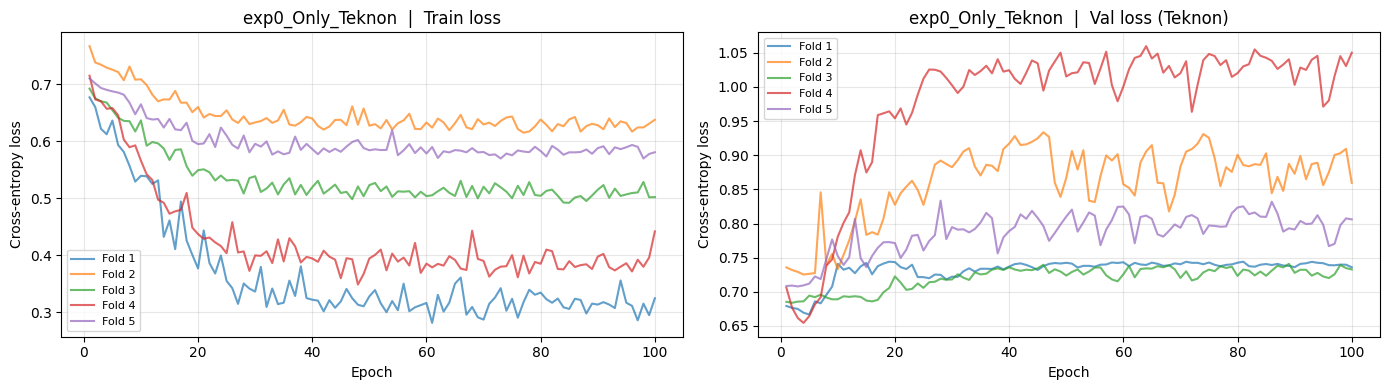

Starting combination: exp1 - Sims_Teknon
  → Training Fold 1/5...
  → Training Fold 2/5...
  → Training Fold 3/5...
  → Training Fold 4/5...
  → Training Fold 5/5...
exp1 has ended -> F1 Mean on Teknon: 0.5553
  → Evaluating the best model from CV on the Teknon Test Set...


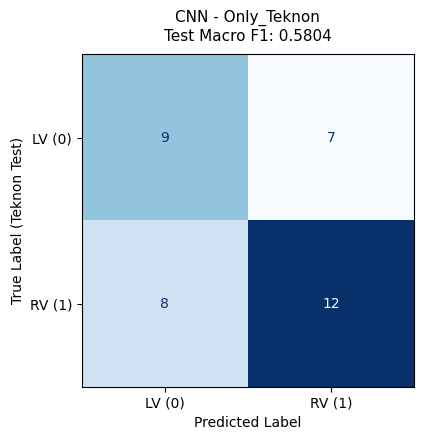

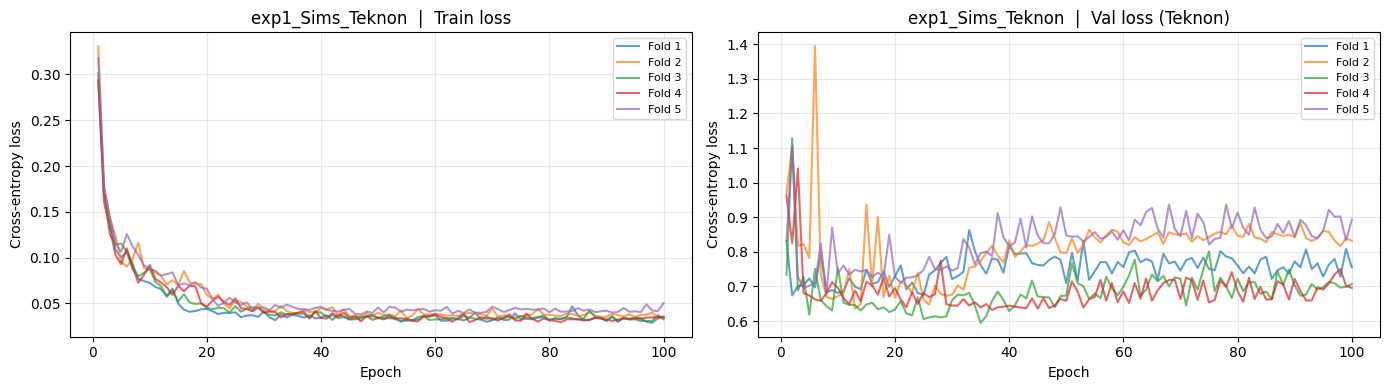

Starting combination: exp2 - China_Teknon
  → Training Fold 1/5...
  → Training Fold 2/5...
  → Training Fold 3/5...
  → Training Fold 4/5...
  → Training Fold 5/5...
exp2 has ended -> F1 Mean on Teknon: 0.5406
  → Evaluating the best model from CV on the Teknon Test Set...


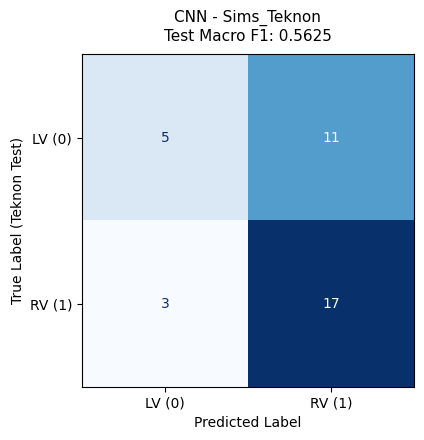

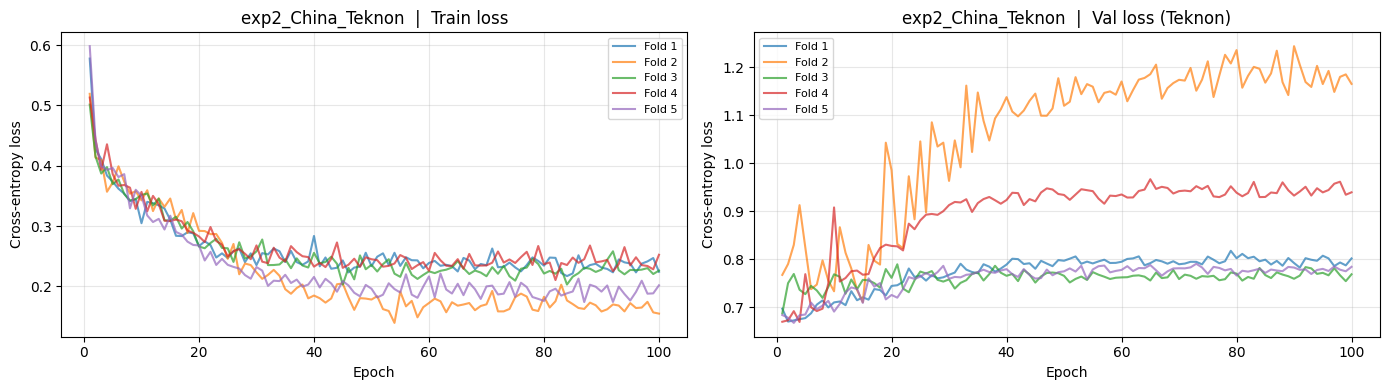

Starting combination: exp3 - CARTO_Teknon
  → Training Fold 1/5...
  → Training Fold 2/5...
  → Training Fold 3/5...
  → Training Fold 4/5...
  → Training Fold 5/5...
exp3 has ended -> F1 Mean on Teknon: 0.5321
  → Evaluating the best model from CV on the Teknon Test Set...


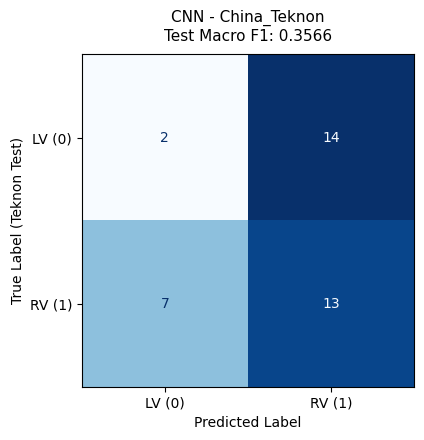

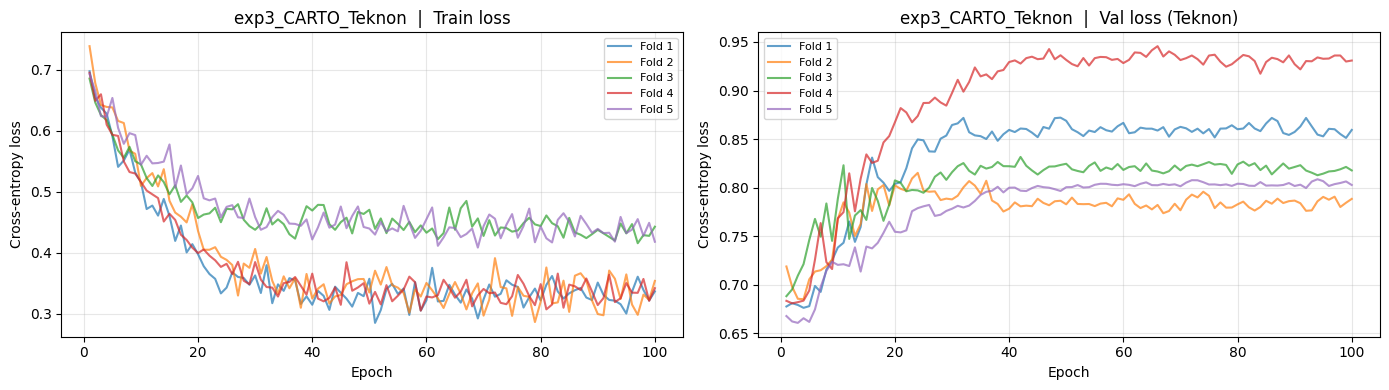

Starting combination: exp4 - China_Sims_Teknon
  → Training Fold 1/5...
  → Training Fold 2/5...
  → Training Fold 3/5...
  → Training Fold 4/5...
  → Training Fold 5/5...
exp4 has ended -> F1 Mean on Teknon: 0.4777
  → Evaluating the best model from CV on the Teknon Test Set...


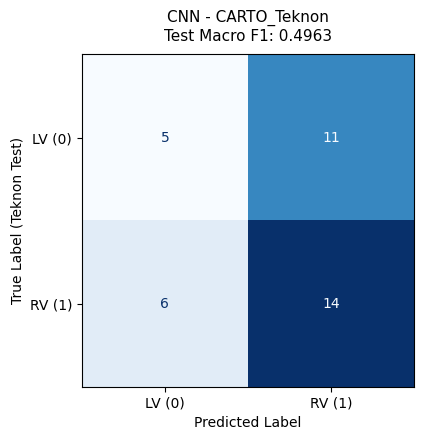

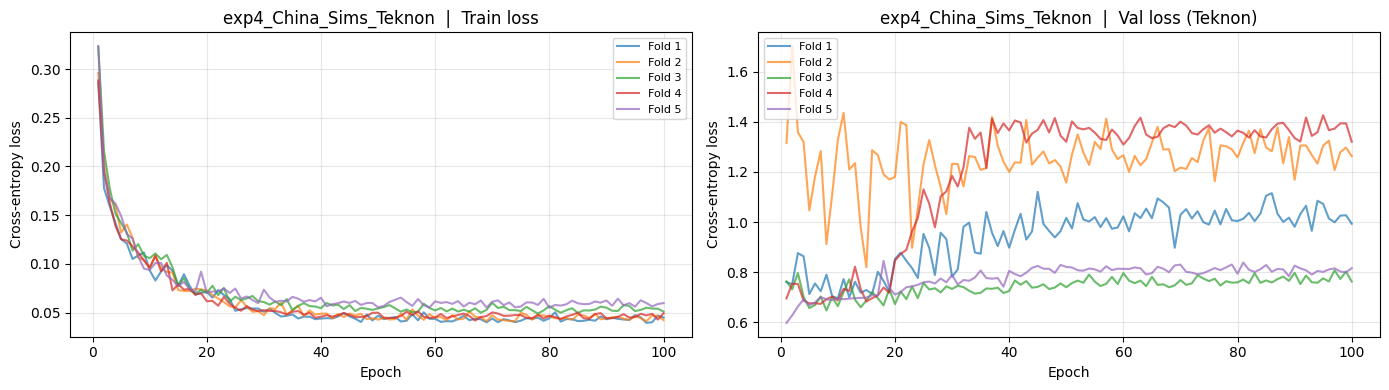

Starting combination: exp5 - CARTO_Sims_Teknon
  → Training Fold 1/5...
  → Training Fold 2/5...
  → Training Fold 3/5...
  → Training Fold 4/5...
  → Training Fold 5/5...
exp5 has ended -> F1 Mean on Teknon: 0.5631
  → Evaluating the best model from CV on the Teknon Test Set...


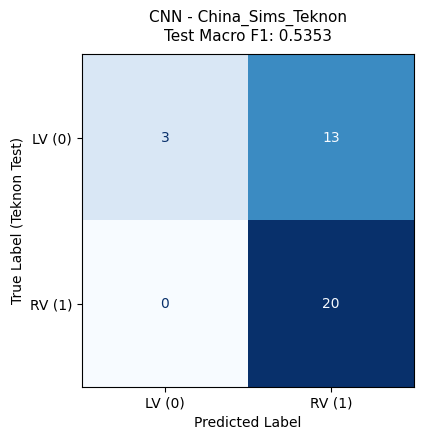

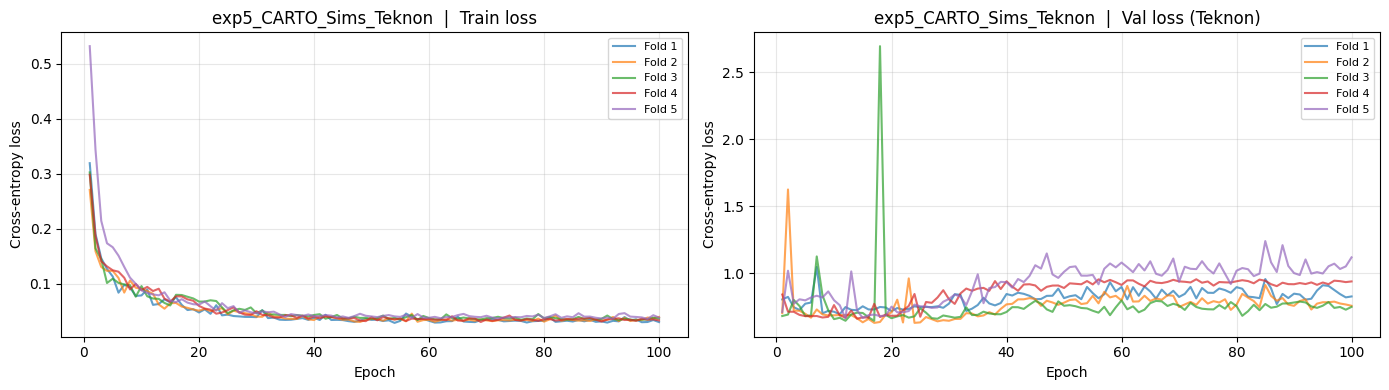

Starting combination: exp6 - CARTO_China_Teknon
  → Training Fold 1/5...
  → Training Fold 2/5...
  → Training Fold 3/5...
  → Training Fold 4/5...
  → Training Fold 5/5...
exp6 has ended -> F1 Mean on Teknon: 0.5647
  → Evaluating the best model from CV on the Teknon Test Set...


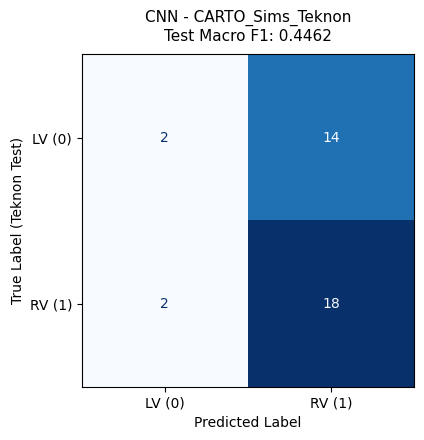

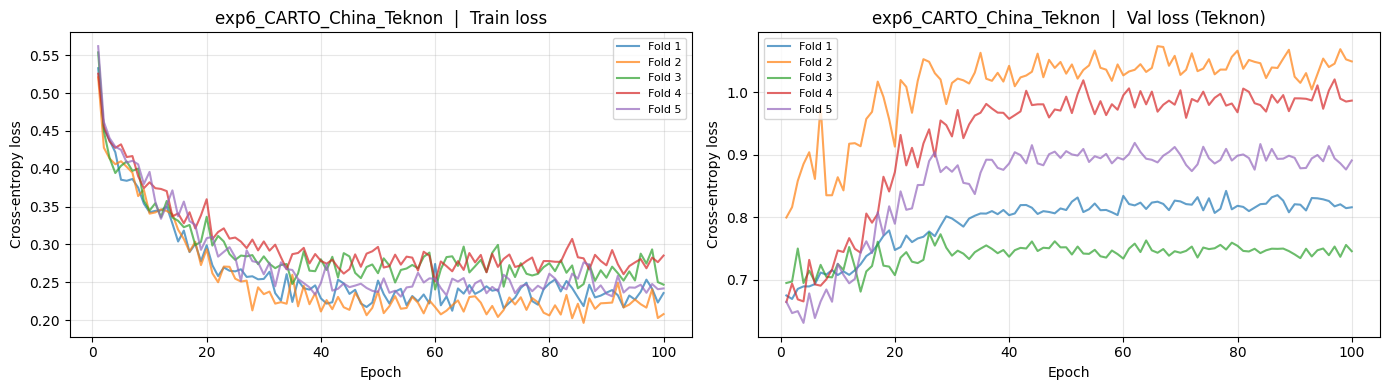

Starting combination: exp7 - ALL_Combined
  → Training Fold 1/5...
  → Training Fold 2/5...
  → Training Fold 3/5...
  → Training Fold 4/5...
  → Training Fold 5/5...
exp7 has ended -> F1 Mean on Teknon: 0.5444
  → Evaluating the best model from CV on the Teknon Test Set...


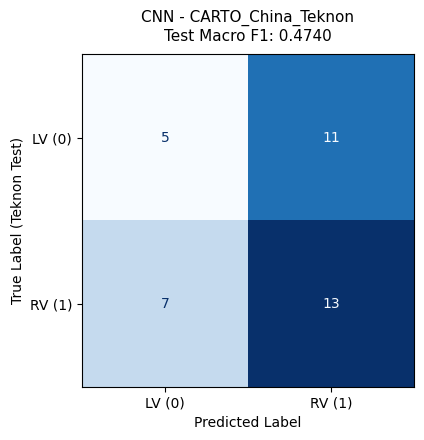

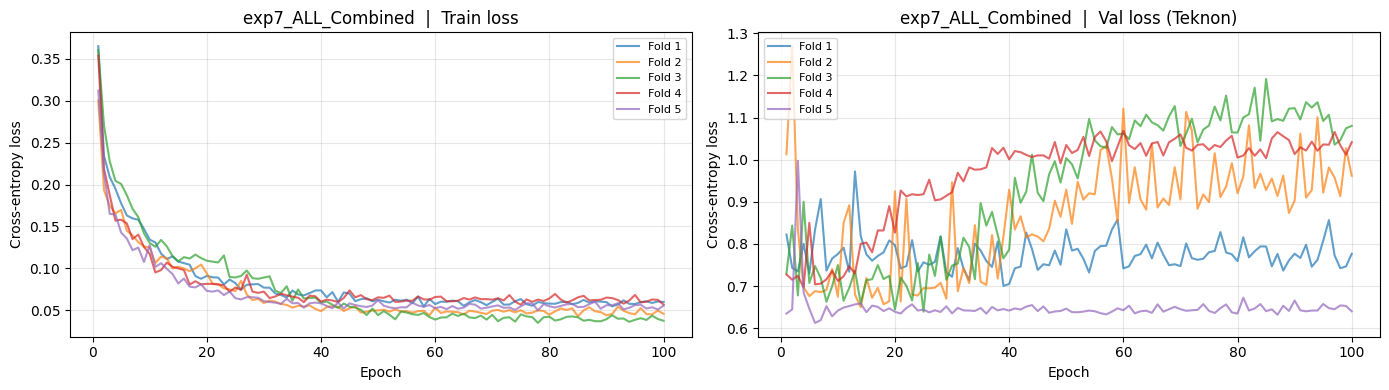


Summary of CNN Results:


,Experiment,CNN F1
0,exp0: Only Teknon,0.509616
1,exp1: Sims + Teknon,0.555253
2,exp2: China + Teknon,0.540636
3,exp3: CARTO + Teknon,0.532137
4,exp4: China + Sims + Teknon,0.477737
5,exp5: CARTO + Sims + Teknon,0.563134
6,exp6: CARTO + China + Teknon,0.564665
7,exp7: All datasets,0.544417


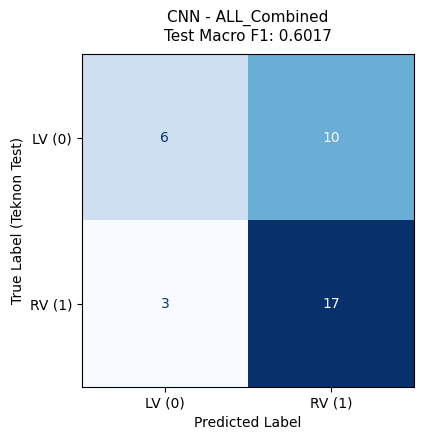

In [63]:
# Experiment loop (exp0 to exp7)
resum_global_cnn = []

# exp0: Only Teknon
f1_0 = run_experiment_cnn('exp0', 'Only_Teknon', X_teknon, y_teknon, X_test, y_test)
resum_global_cnn.append({'Experiment': 'exp0: Only Teknon', 'CNN F1': f1_0})

# exp1: Sims + Tek
f1_1 = run_experiment_cnn('exp1', 'Sims_Teknon', X_teknon, y_teknon, X_test, y_test, X_Sims, y_Sims)
resum_global_cnn.append({'Experiment': 'exp1: Sims + Teknon', 'CNN F1': f1_1})

# exp2: China + Tek
f1_2 = run_experiment_cnn('exp2', 'China_Teknon', X_teknon, y_teknon, X_test, y_test, X_China, y_China)
resum_global_cnn.append({'Experiment': 'exp2: China + Teknon', 'CNN F1': f1_2})

# exp3: Clinic (CARTO) + Tek
f1_3 = run_experiment_cnn('exp3', 'CARTO_Teknon', X_teknon, y_teknon, X_test, y_test, X_Clinic, y_Clinic)
resum_global_cnn.append({'Experiment': 'exp3: CARTO + Teknon', 'CNN F1': f1_3})

# exp4: China + Sims + Tek
X_e4 = np.concatenate([X_China, X_Sims], axis=0)
y_e4 = np.concatenate([y_China, y_Sims], axis=0)
f1_4 = run_experiment_cnn('exp4', 'China_Sims_Teknon', X_teknon, y_teknon, X_test, y_test, X_e4, y_e4)
resum_global_cnn.append({'Experiment': 'exp4: China + Sims + Teknon', 'CNN F1': f1_4})

# exp5: Clinic + Sims + Tek
X_e5 = np.concatenate([X_Clinic, X_Sims], axis=0)
y_e5 = np.concatenate([y_Clinic, y_Sims], axis=0)
f1_5 = run_experiment_cnn('exp5', 'CARTO_Sims_Teknon',X_teknon, y_teknon, X_test, y_test, X_e5, y_e5)
resum_global_cnn.append({'Experiment': 'exp5: CARTO + Sims + Teknon', 'CNN F1': f1_5})

# exp6: Clinic + China + Tek
X_e6 = np.concatenate([X_Clinic, X_China], axis=0)
y_e6 = np.concatenate([y_Clinic, y_China], axis=0)
f1_6 = run_experiment_cnn('exp6', 'CARTO_China_Teknon', X_teknon, y_teknon, X_test, y_test, X_e6, y_e6)
resum_global_cnn.append({'Experiment': 'exp6: CARTO + China + Teknon', 'CNN F1': f1_6})

# exp7: ALL
X_all = np.concatenate([X_Clinic, X_China, X_Sims], axis=0)
y_all = np.concatenate([y_Clinic, y_China, y_Sims], axis=0)
f1_7 = run_experiment_cnn('exp7', 'ALL_Combined', X_teknon, y_teknon, X_test, y_test, X_all, y_all)
resum_global_cnn.append({'Experiment': 'exp7: All datasets', 'CNN F1': f1_7})


# Show the summary table for CNN results
df_final_cnn = pd.DataFrame(resum_global_cnn)
print("\nSummary of CNN Results:")
display(df_final_cnn)

Display the Cross-Validation plots for all the assessed dataset combinations and algorithms. Including the four basic ML algorithms and the CNN.

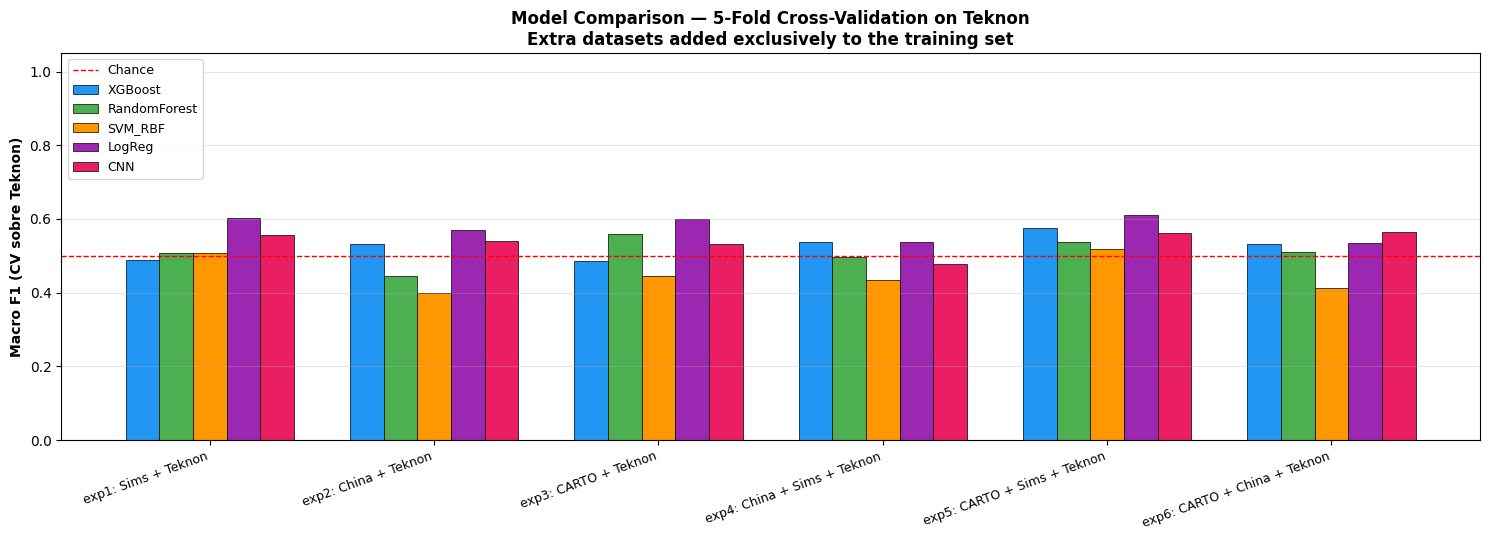

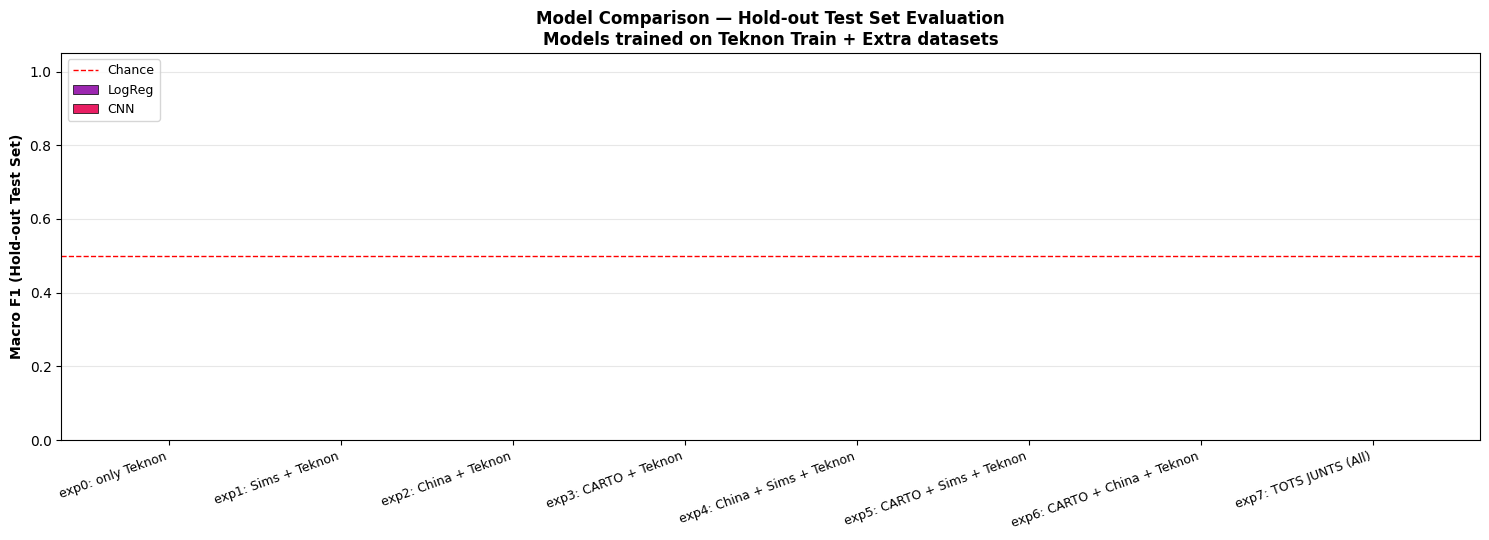

In [65]:
# Preparate dataframes with the ML results
df_ml_cv = pd.DataFrame(resum_real).set_index('Experiment')
df_ml_cv.columns = [col.replace(' (Macro F1)', '') for col in df_ml_cv.columns]
df_ml_test = pd.DataFrame(results).set_index('Experiment')

# Join it with the CNN result, ensuring that the 'Experiment' column is consistent
if 'Experiment' in df_final_cnn.columns:
    df_final_cnn = df_final_cnn.set_index('Experiment')

cnn_cv_col = 'CNN F1' if 'CNN F1' in df_final_cnn.columns else df_final_cnn.columns[0]

# Combination for Cross-Validation results
df_resum = df_ml_cv.join(df_final_cnn[[cnn_cv_col]], how='inner')
df_resum.rename(columns={cnn_cv_col: 'CNN'}, inplace=True)

# Combination for Hold-out (Test Set) results
df_holdout = pd.DataFrame(index=df_ml_cv.index)
df_holdout['LogReg'] = df_ml_test['Test Macro F1']

# Add CNN results to the hold-out dataframe, if available. If not, set to NaN or 0 as a placeholder.
if 'CNN (Macro F1 Test)' in df_final_cnn.columns:
    df_holdout['CNN'] = df_final_cnn['CNN (Macro F1 Test)']
else:
    df_holdout['CNN'] = 0.0

df_holdout.fillna(0, inplace=True)

# Plot configuration
model_names_cv = ['XGBoost', 'RandomForest', 'SVM_RBF', 'LogReg', 'CNN']
colors_cv = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']

model_names_test = ['LogReg', 'CNN']
colors_test = ['#9C27B0', '#E91E63']

# Cross-validation plot
x = np.arange(len(df_resum))
width = 0.15

fig, ax = plt.subplots(figsize=(15, 5.5))
for i, (m, c) in enumerate(zip(model_names_cv, colors_cv)):
    ax.bar(x + i * width, df_resum[m], width, label=m, color=c,
           edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_resum.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Macro F1 (CV sobre Teknon)', fontweight='bold')
ax.set_title('Model Comparison — 5-Fold Cross-Validation on Teknon\nExtra datasets added exclusively to the training set', fontweight='bold', fontsize=12)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Chance')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

# Test set plot
x2 = np.arange(len(df_holdout))
width2 = 0.25

fig2, ax2 = plt.subplots(figsize=(15, 5.5))
for i, (m, c) in enumerate(zip(model_names_test, colors_test)):
    ax2.bar(x2 + i * width2, df_holdout[m], width2, label=m, color=c,
            edgecolor='black', linewidth=0.5)

ax2.set_xticks(x2 + width2 * 0.5)
ax2.set_xticklabels(df_holdout.index, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Macro F1 (Hold-out Test Set)', fontweight='bold')
ax2.set_title('Model Comparison — Hold-out Test Set Evaluation\nModels trained on Teknon Train + Extra datasets', fontweight='bold', fontsize=12)
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Chance')
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

### 3. CNN & MLP on Raw and Clinical Data
This third experiment aims to evaluate if clinical data (given only for teknon) adds relevant information to the classification task.
The clinical data will be included to the deep learning algorithm with a Multylayer Percepton of two layers. The deepness was chosen to include two hidden layers (and not more) because the data is quite simple and more layers would probably be counterproductive. 
Since the previous results (for only the CNN) were unconclusive regarding which dataset combination gave the best performance, all datasets were selected under the assumption that more data would perform a better generalization.

We only reload Teknon to ensure the splits are redone and the data is not leaked. China, Clínic and Sims since they are already loaded in the cells above, they are reused.

In [66]:
# Data loading and preparation
df = pd.read_parquet(PATH_DATA)
df.drop(LEADS, axis=1, inplace=True, errors='ignore')

# Initial imputation for specific categorical/binary indicators
cols_binary = ['HTA', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'Sex']
df[cols_binary] = df[cols_binary].fillna(0)

X_tabular_raw = df.drop(['Chamber_Type', 'patient_id'], axis=1, errors='ignore')
Y_tabular_raw = df['Chamber_Type']

# ECG Data Loading and Synchronization
with open(PATH_ALIGNED, 'rb') as f:
    X_teknon_all = np.array(pickle.load(f), dtype=np.float32)

# Ensure correct dimensions: (batch, leads, time)
if X_teknon_all.shape[1] == 277:
    X_teknon_all = np.transpose(X_teknon_all, (0, 2, 1))

with open(PATH_IDENTIFIERS, 'rb') as f:
    df_id = pickle.load(f)

# Synchronize tabular data and ECG time series by common indices
indices_common = df_id.index.intersection(X_tabular_raw.index)
print(f"Synchronization stats:")
print(f" - Available ECGs: {len(df_id)}")
print(f" - Available Tabular Rows: {len(X_tabular_raw)}")
print(f" - Synchronized Patients: {len(indices_common)}")

X_tab_sync = X_tabular_raw.loc[indices_common].copy()
y_sync = Y_tabular_raw.loc[indices_common].values

pos_ecg = [df_id.index.get_loc(idx) for idx in indices_common]
X_ecg_sync = X_teknon_all[pos_ecg]

#### Dataset Splitting (80-20) as required, split the tabular, ecg and labels
split_idx = int(0.8 * len(indices_common))

X_tab_train = X_tab_sync.iloc[:split_idx].copy()
X_tab_test  = X_tab_sync.iloc[split_idx:].copy()

X_ecg_train = X_ecg_sync[:split_idx]
X_ecg_test  = X_ecg_sync[split_idx:]

y_train_tk = y_sync[:split_idx]
y_test_tk  = y_sync[split_idx:]

print(f"\nDataset Split:")
print(f" - Train set size: {X_tab_train.shape[0]}")
print(f" - Test set size: {X_tab_test.shape[0]}")

Synchronization stats:
 - Available ECGs: 178
 - Available Tabular Rows: 180
 - Synchronized Patients: 177

Dataset Split:
 - Train set size: 141
 - Test set size: 36


In [67]:
#### Imputation and Scaling of Tabular Data
cols_numeric = ['Age', 'Height', 'Weight', 'BMI', 'CLINICAL_SCORE', 'missing_rate']

# Compute statistics exclusively from the training partition
train_score_median = X_tab_train['CLINICAL_SCORE'].median()
train_age_mean = X_tab_train['Age'].mean()

X_tab_train['CLINICAL_SCORE'] = X_tab_train['CLINICAL_SCORE'].fillna(train_score_median)
X_tab_test['CLINICAL_SCORE']  = X_tab_test['CLINICAL_SCORE'].fillna(train_score_median)

X_tab_train['Age'] = X_tab_train['Age'].fillna(train_age_mean)
X_tab_test['Age']  = X_tab_test['Age'].fillna(train_age_mean)

# Fit scaler on train data and transform both partitions
scaler = StandardScaler()
X_tab_train[cols_numeric] = scaler.fit_transform(X_tab_train[cols_numeric])
X_tab_test[cols_numeric]  = scaler.transform(X_tab_test[cols_numeric])

X_train_np = X_tab_train.astype(float).values
X_test_np  = X_tab_test.astype(float).values

# Instantiate PyTorch Datasets (train-val teknon will be instantiated inside the fold loop for every split)
n_feat = X_train_np.shape[1]
ds_teknon_test = UniversalECGDataset(X_ecg_test, y_test_tk, X_tabular=X_test_np, num_tab_features=n_feat, return_tab=True)
test_loader = DataLoader(ds_teknon_test, batch_size=BATCH_SIZE, shuffle=False)

ds_china  = UniversalECGDataset(X_China, y_China, num_tab_features=n_feat, return_tab=True)
ds_sims   = UniversalECGDataset(X_Sims, y_Sims, num_tab_features=n_feat, return_tab=True)
ds_clinic = UniversalECGDataset(X_Clinic, y_Clinic, num_tab_features=n_feat, return_tab=True)



--- Training Fold 1/5 ---
 Epoch 05: Train Loss 0.1354 | Val Acc 62.07%
 Epoch 10: Train Loss 0.0943 | Val Acc 58.62%
 Epoch 15: Train Loss 0.0804 | Val Acc 58.62%
 Epoch 20: Train Loss 0.0762 | Val Acc 65.52%

--- Training Fold 2/5 ---
 Epoch 05: Train Loss 0.1403 | Val Acc 67.86%
 Epoch 10: Train Loss 0.0956 | Val Acc 60.71%
 Epoch 15: Train Loss 0.0826 | Val Acc 64.29%
 Epoch 20: Train Loss 0.0808 | Val Acc 75.00%

--- Training Fold 3/5 ---
 Epoch 05: Train Loss 0.1247 | Val Acc 60.71%
 Epoch 10: Train Loss 0.1047 | Val Acc 57.14%
 Epoch 15: Train Loss 0.0808 | Val Acc 67.86%
 Epoch 20: Train Loss 0.0721 | Val Acc 64.29%

--- Training Fold 4/5 ---
 Epoch 05: Train Loss 0.1291 | Val Acc 64.29%
 Epoch 10: Train Loss 0.0919 | Val Acc 67.86%
 Epoch 15: Train Loss 0.0806 | Val Acc 64.29%
 Epoch 20: Train Loss 0.0753 | Val Acc 67.86%

--- Training Fold 5/5 ---
 Epoch 05: Train Loss 0.1356 | Val Acc 64.29%
 Epoch 10: Train Loss 0.1049 | Val Acc 67.86%
 Epoch 15: Train Loss 0.0807 | Val Ac

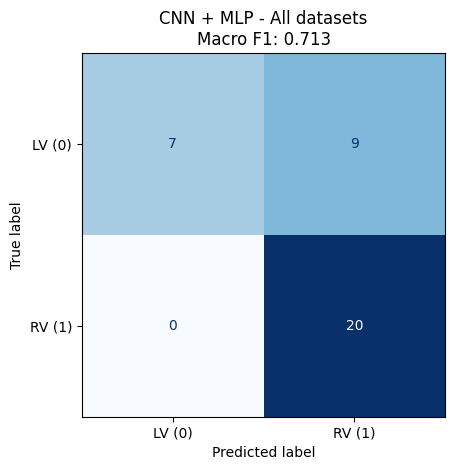

In [68]:
# Cross-Validation
from sklearn.metrics import ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Stratified K-Fold cross-validation loop
fold_results = {}
for fold, (train_ids, val_ids) in enumerate(skf.split(X_ecg_train, y_train_tk), 1):
    print(f'\n--- Training Fold {fold}/{N_FOLDS} ---')

    # Split the Teknon train
    X_ecg_fold_train = X_ecg_train[train_ids]
    y_fold_train     = y_train_tk[train_ids]
    X_tab_fold_train = X_train_np[train_ids]

    X_ecg_fold_val   = X_ecg_train[val_ids]
    y_fold_val       = y_train_tk[val_ids]
    X_tab_fold_val   = X_train_np[val_ids]

    # Initialize train-val datasets and loaders for this fold
    ds_fold_train = ConcatDataset([
        UniversalECGDataset(X_ecg_fold_train, y_fold_train, X_tabular=X_tab_fold_train, num_tab_features=n_feat, return_tab=True),
        ds_china, ds_sims, ds_clinic])
    ds_fold_val = UniversalECGDataset(X_ecg_fold_val, y_fold_val, X_tabular=X_tab_fold_val, num_tab_features=n_feat, return_tab=True)
    train_loader = DataLoader(ds_fold_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(ds_fold_val,   batch_size=BATCH_SIZE, shuffle=False)

    # Late Fusion Model initialization
    cnn_net = ECG_CNN_Cropped(n_leads=12).to(device)
    mlp_net = ClinicalMLP(input_size=n_feat).to(device)
    model = GlobalFusionModel(cnn_net, mlp_net).to(device)

    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # Epoch loop for training and validation
    num_epochs = 20
    for epoch in range(num_epochs):
        t_loss, t_acc = train_model(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = validate_model(model, val_loader, criterion, device)
        if (epoch + 1) % 5 == 0:
            print(f" Epoch {epoch+1:02d}: Train Loss {t_loss:.4f} | Val Acc {v_acc:.2f}%")

    fold_results[fold] = v_acc

print(f'\nMean K-Fold Accuracy: {np.mean(list(fold_results.values())):.2f}%')

#### Evaluation on teknon held-out test set
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs_ecg, inputs_tab, labels in test_loader:
        inputs_ecg, inputs_tab, labels = inputs_ecg.to(device), inputs_tab.to(device), labels.to(device)
        outputs = model(inputs_ecg, inputs_tab)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print("\n=== Final Test Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=['LV', 'RV']))

macro_f1= f1_score(all_labels,all_preds, average='macro')
print(f"Macro F1: {macro_f1:.3f}")

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LV (0)', 'RV (1)'])
disp.plot(cmap='Blues', colorbar=False, values_format='d')
plt.title(f'CNN + MLP - All datasets\nMacro F1: {macro_f1:.3f}')
plt.tight_layout()
plt.show()

Finally, we do a shap analysis for the combined approach (CNN+MLP) to see if the tabular data appear as relevant features

Training final model for SHAP...
  Epoch 05: Train Loss 0.1204 | Train Acc 95.15%
  Epoch 10: Train Loss 0.1049 | Train Acc 95.62%
  Epoch 15: Train Loss 0.0932 | Train Acc 96.32%
  Epoch 20: Train Loss 0.0713 | Train Acc 96.78%
Background shape: torch.Size([100, 3338])
Test shape:       torch.Size([36, 3338])
Computing SHAP values with DeepExplainer (this may take a minute)...
shap_array shape: (2, 36, 3338)

TOP TABULAR FEATURES BY SHAP:


,feature,mean_abs_shap
3,PVC_transition,1.261643
4,Height,0.200075
5,Weight,0.181947
2,Age,0.168440
12,CLINICAL_SCORE,0.148953
6,BMI,0.135062
1,HTA,0.114660
0,Sex,0.094086
13,missing_rate,0.064465
7,DM,0.041601


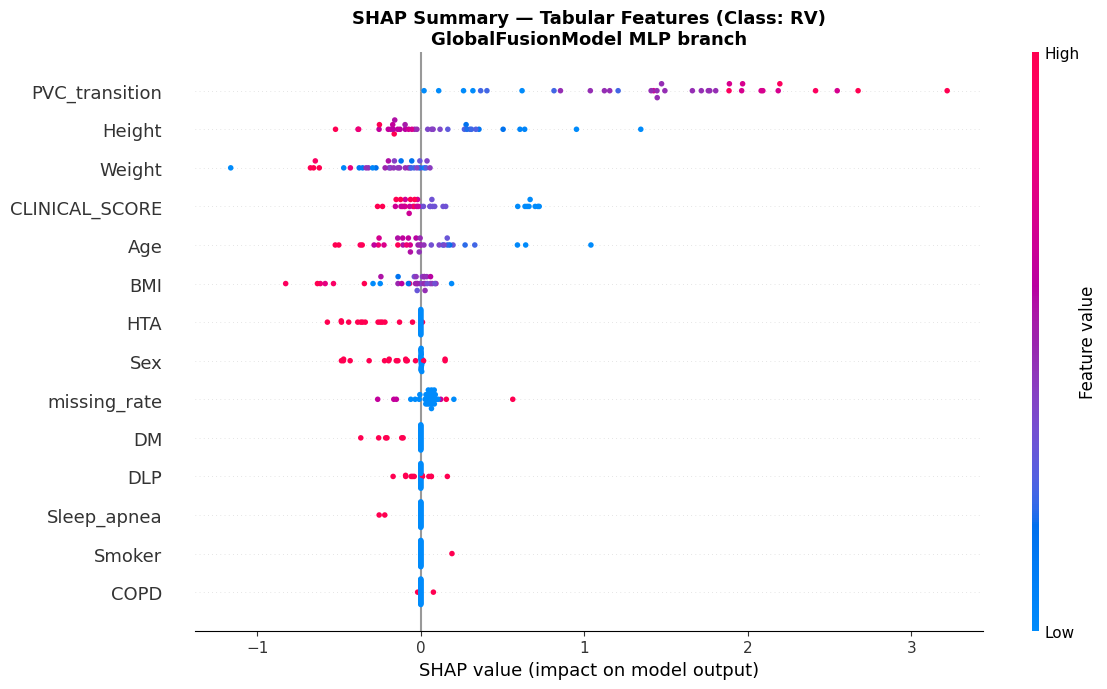

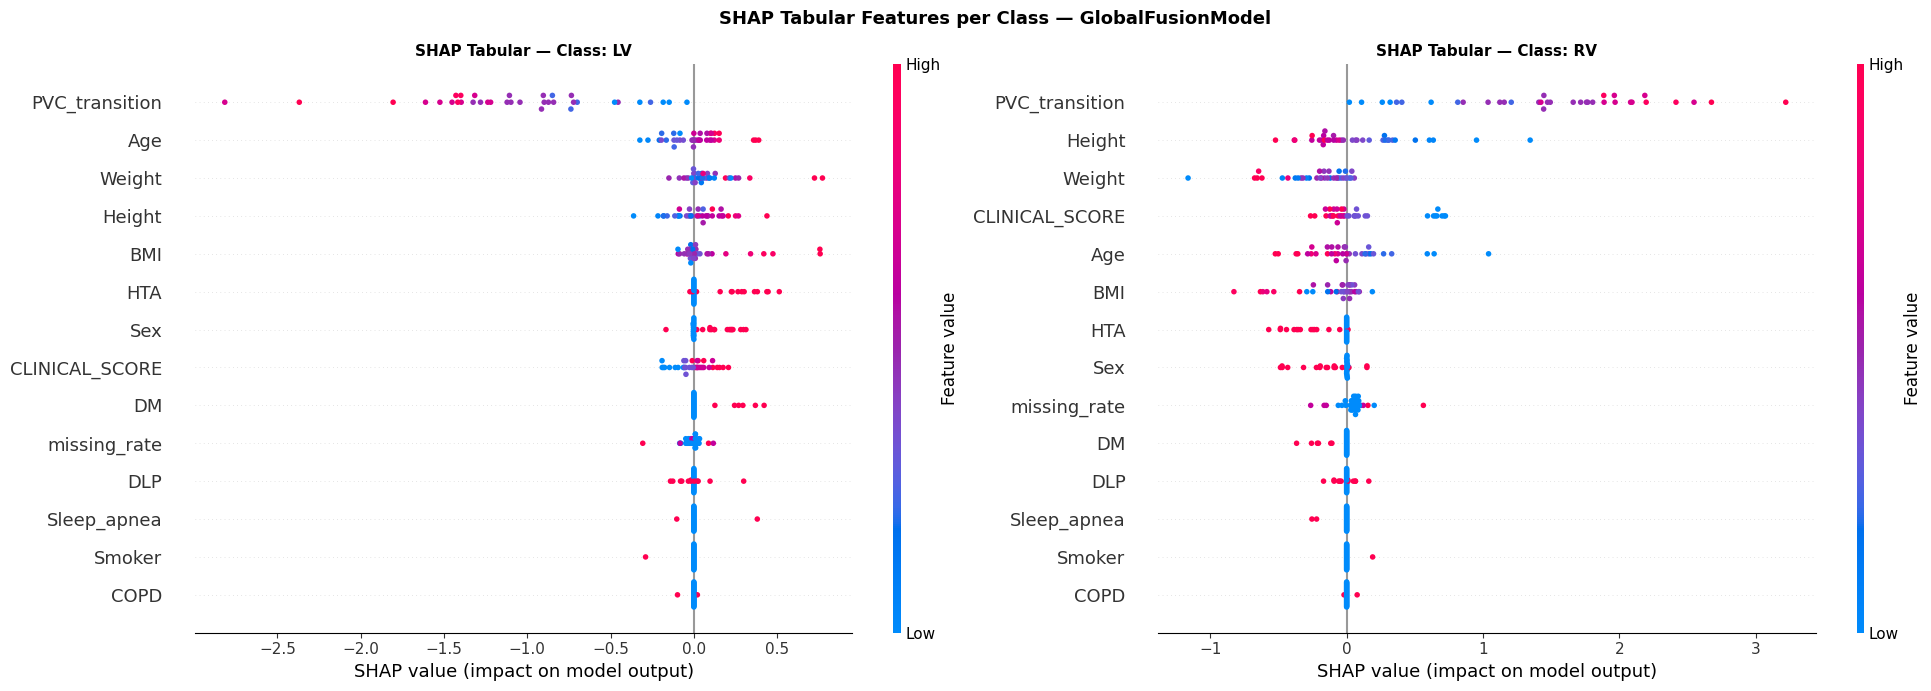


ECG LEAD IMPORTANCE (mean |SHAP| across time):


,lead,mean_abs_shap
6,V1,0.000665
3,aVR,0.000554
7,V2,0.000449
9,V4,0.000431
10,V5,0.000429
8,V3,0.000427
1,II,0.000404
11,V6,0.000350
2,III,0.000347
5,aVF,0.000339


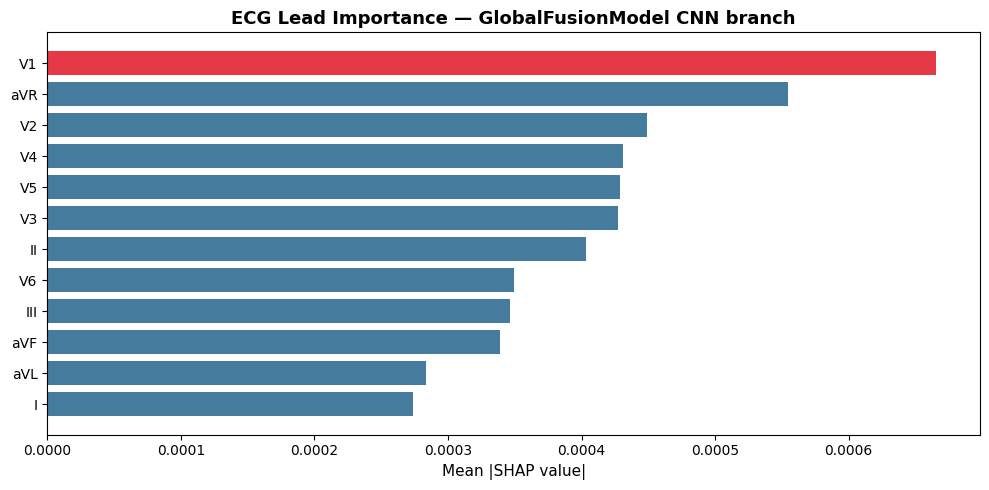

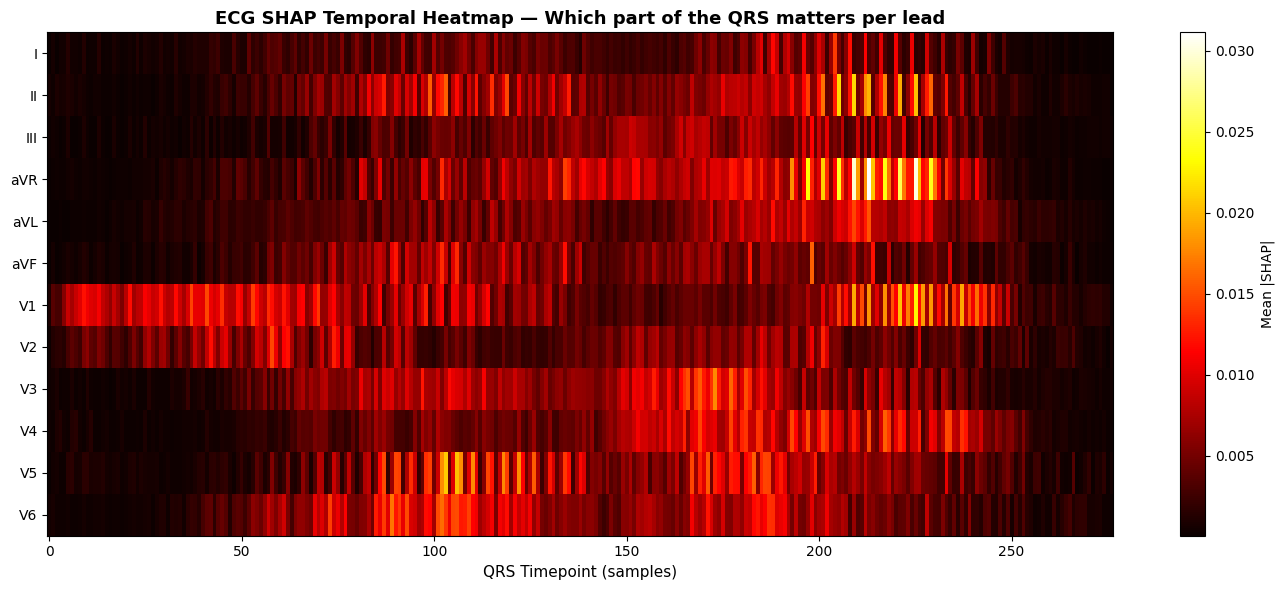

In [78]:
# REdefine the full train dataset
full_train_dataset = ConcatDataset([
    UniversalECGDataset(X_ecg_train, y_train_tk, X_tabular=X_train_np, num_tab_features=n_feat, return_tab=True), 
    ds_china, ds_sims, ds_clinic])

# Re-train one final model on full_train_dataset (no CV, just for SHAP)
final_train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

# Redefine the models
cnn_net_final = ECG_CNN_Cropped(n_leads=12).to(device)
mlp_net_final = ClinicalMLP(input_size=n_feat).to(device)
shap_model = GlobalFusionModel(cnn_net_final, mlp_net_final).to(device)

#Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(shap_model.parameters(), lr=0.001, weight_decay=1e-4)

print("Training final model for SHAP...")
for epoch in range(20):
    t_loss, t_acc = train_model(shap_model, final_train_loader, criterion, optimizer, device)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:02d}: Train Loss {t_loss:.4f} | Train Acc {t_acc:.2f}%")

shap_model.eval()

# Collect all test samples as tensors
all_ecg_test, all_tab_test, all_labels_test = [], [], []
for ecg, tab, label in ds_teknon_test:
    all_ecg_test.append(ecg)
    all_tab_test.append(tab)
    all_labels_test.append(label)

all_ecg_test = torch.stack(all_ecg_test).to(device)   # (N, 12, 277)
all_tab_test = torch.stack(all_tab_test).to(device)   # (N, n_feat)

# Background: 100 random train samples (needed by DeepExplainer as reference)
bg_ecg, bg_tab = [], []
bg_loader = DataLoader(full_train_dataset, batch_size=256, shuffle=True)
for ecg, tab, _ in bg_loader:
    bg_ecg.append(ecg)
    bg_tab.append(tab)
    break  # just first batch

bg_ecg = bg_ecg[0][:100].to(device)  # (100, 12, 277)
bg_tab = bg_tab[0][:100].to(device)  # (100, n_feat)

# DeepExplainer needs a single-call model; wrap it
class FusionWrapper(nn.Module):
    """Splits a flat input vector back into (ecg, tab) and calls GlobalFusionModel."""
    def __init__(self, model, ecg_shape):
        super().__init__()
        self.model = model
        self.ecg_flat_size = ecg_shape[0] * ecg_shape[1]  # 12 * 277 = 3324

    def forward(self, x):
        x_ecg = x[:, :self.ecg_flat_size].view(x.size(0), 12, 277)
        x_tab = x[:, self.ecg_flat_size:]
        return self.model(x_ecg, x_tab)

ecg_shape = (12, 277)
wrapper = FusionWrapper(shap_model, ecg_shape).to(device)
wrapper.eval()

# Flatten inputs for DeepExplainer
bg_flat   = torch.cat([bg_ecg.view(100, -1), bg_tab], dim=1)       # (100, 3324 + n_feat)
test_flat = torch.cat([all_ecg_test.view(len(all_ecg_test), -1), all_tab_test], dim=1)

print(f"Background shape: {bg_flat.shape}")
print(f"Test shape:       {test_flat.shape}")

print("Computing SHAP values with DeepExplainer (this may take a minute)...")

explainer = shap.GradientExplainer(wrapper, bg_flat)
shap_values = explainer.shap_values(test_flat[:50])  # limit to 50 for speed; increase if GPU

# shap_values: list of 2 arrays (one per class), each (50, 3324 + n_feat)
shap_array = np.array(shap_values)  # (2, 50, total_features)
print(f"shap_array shape: {shap_array.shape}")

ecg_flat_size = 12 * 277  # 3324

# ECG portion
shap_ecg  = shap_array[:, :, :ecg_flat_size]   # (2, 50, 3324)
# Tabular portion
shap_tab  = shap_array[:, :, ecg_flat_size:]    # (2, 50, n_feat)

test_tab_np = all_tab_test[:50].cpu().numpy()   # (50, n_feat)

# Tabular feature names (from your pipeline)
tab_feature_names = list(X_tab_sync.columns)

# Mean |SHAP| across both classes and all samples
mean_abs_tab = np.abs(shap_tab).mean(axis=(0, 1))  # (n_feat,)

df_shap_tab = pd.DataFrame({
    "feature": tab_feature_names,
    "mean_abs_shap": mean_abs_tab
}).sort_values("mean_abs_shap", ascending=False)

print("\nTOP TABULAR FEATURES BY SHAP:")
display(df_shap_tab.head(20))

shap_tab_class1 = shap_tab[1]  # (50, n_feat) — SHAP for class RV

plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_tab_class1,
    test_tab_np,
    feature_names=tab_feature_names,
    max_display=20,
    show=False,
    plot_size=(12, 7)
)
plt.title("SHAP Summary — Tabular Features (Class: RV)\nGlobalFusionModel MLP branch",
          fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for cls_idx, cls_name in enumerate(['LV', 'RV']):
    plt.sca(axes[cls_idx])
    shap.summary_plot(
        shap_tab[cls_idx],
        test_tab_np,
        feature_names=tab_feature_names,
        max_display=15,
        show=False,
        plot_size=None
    )
    axes[cls_idx].set_title(f"SHAP Tabular — Class: {cls_name}", fontsize=11, weight='bold')

plt.suptitle("SHAP Tabular Features per Class — GlobalFusionModel", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

shap_ecg_reshaped = shap_ecg.mean(axis=0)          # avg across classes: (50, 3324)
shap_ecg_reshaped = shap_ecg_reshaped.reshape(36, 12, 277)  # (36, leads, time)

lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

# Mean |SHAP| per lead (across time and samples)
lead_importance = np.abs(shap_ecg_reshaped).mean(axis=(0, 2))  # (12,)

df_leads = pd.DataFrame({
    "lead": lead_names,
    "mean_abs_shap": lead_importance
}).sort_values("mean_abs_shap", ascending=False)

print("\nECG LEAD IMPORTANCE (mean |SHAP| across time):")
display(df_leads)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e63946' if v == lead_importance.max() else '#457b9d' for v in df_leads['mean_abs_shap']]
bars = ax.barh(df_leads['lead'], df_leads['mean_abs_shap'], color=colors)
ax.set_xlabel("Mean |SHAP value|", fontsize=11)
ax.set_title("ECG Lead Importance — GlobalFusionModel CNN branch", fontsize=13, weight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

shap_ecg_temporal = np.abs(shap_ecg).mean(axis=(0, 1)).reshape(12, 277)  # (12, 277)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(shap_ecg_temporal, aspect='auto', cmap='hot', interpolation='nearest')
ax.set_yticks(range(12))
ax.set_yticklabels(lead_names)
ax.set_xlabel("QRS Timepoint (samples)", fontsize=11)
ax.set_title("ECG SHAP Temporal Heatmap — Which part of the QRS matters per lead",
             fontsize=13, weight='bold')
plt.colorbar(im, ax=ax, label='Mean |SHAP|')
plt.tight_layout()
plt.show()